In [ ]:
''' Nombre de los integrantes:
Dishley Sylvain
Nombre del dataset utilizado:
Medical Insurance Cost Dataset (insurance.csv)
Fuente del dataset:
El dataset proviene del libro "Machine Learning with R" de Brett Lantz, disponible públicamente en GitHub: github.com/stedy/Machine-Learning-with-R-datasets
Breve resumen del análisis realizado:
Se realizó un Análisis Exploratorio de Datos (EDA) sobre un dataset de costos de seguros médicos con 1,338 registros y 7 variables. El análisis incluyó la identificación y clasificación de variables (nominales, discretas y continuas), análisis descriptivo (media, mediana, moda, desviación estándar, cuartiles), análisis de distribuciones mediante histogramas y boxplots, y pruebas estadísticas de hipótesis (t-test). Se encontró que el tabaquismo es el factor más determinante en el costo del seguro — los fumadores pagan casi 4 veces más que los no fumadores ($32,050 vs $8,434), con un p-value de 8.27e-283. Se analizó también la relación entre BMI y costo segmentando por estatus de fumador, encontrando una correlación fuerte entre BMI y costo únicamente en fumadores (r=0.81) versus no fumadores (r=0.08). La región Sureste mostró la mayor concentración de fumadores y los costos más extremos.
Principales limitaciones encontradas:
El dataset no contiene información sobre condiciones médicas preexistentes, lo cual limita el poder explicativo del modelo
Las variables categóricas (sex, region) no mostraron significancia estadística sobre el costo, lo que sugiere que el dataset podría estar simplificado o ser sintético
El dataset cubre únicamente 4 regiones de EE.UU. — no es generalizable a otros países o sistemas de salud
La ausencia de valores nulos facilita el análisis pero no refleja la realidad de datos médicos reales, donde los datos faltantes son comunes
Con solo 1,338 registros el dataset es relativamente pequeño para conclusiones estadísticas robustas
'''


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns


url = 'https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv'
df = pd.read_csv(url)
r, c = df.shape
print(f'The data set has {c} columns and {r} rows')
print(f"The dataset originally comes from the book Machine Learning with R by Brett Lantz, and it's hosted on GitHub ")
print(f'con este data set podemos estudiar como incide el tabaco o fumar sobre el costo del seguro o los cargos de seguro.')
print(f'cada fila representa una persona o mas bien una observacion.')
print(f' cada columna representa un attributo o variable')
df.head()


The data set has 7 columns and 1338 rows
The dataset originally comes from the book Machine Learning with R by Brett Lantz, and it's hosted on GitHub 
con este data set podemos estudiar como incide el tabaco o fumar sobre el costo del seguro o los cargos de seguro.
cada fila representa una persona o mas bien una observacion.
 cada columna representa un attributo o variable


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.describe()
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [ ]:
# tipos
for k, v in df.dtypes.items():
    n = df[k].nunique()
    if not pd.api.types.is_numeric_dtype(df[k]):
        if n == 2:
            print(f'{k} → binary')
        else:
            print(f'{k} → nominal')
    elif pd.api.types.is_float_dtype(df[k]):
        print(f'{k} → continuous')
    elif pd.api.types.is_integer_dtype(df[k]) and n < 10:
        print(f'{k} → discrete')
    else:
        print(f'{k} → continuous/ID')


age → continuous/ID
sex → binary
bmi → continuous
children → discrete
smoker → binary
region → nominal
charges → continuous


In [5]:
# valores faltantes?
df.isnull().sum()
print(' there is not missing values')


 there is not missing values


In [6]:
df['age'].skew()
df['age'].mode()


0    18
Name: age, dtype: int64

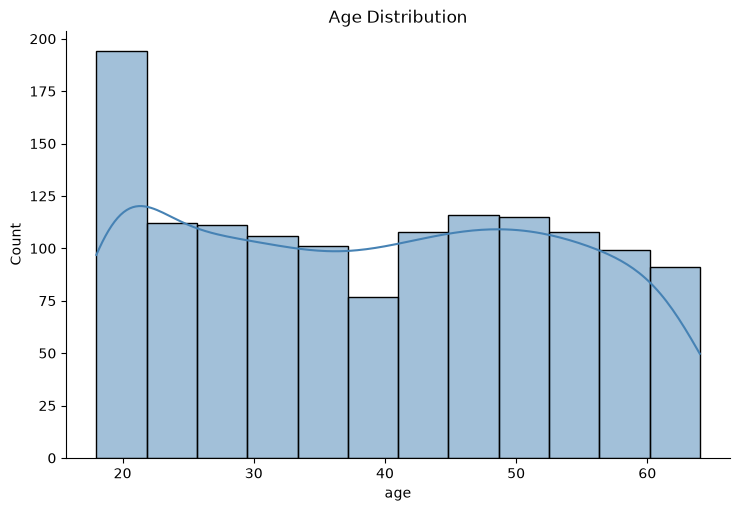

In [7]:
sns.displot(df['age'], kde=True, color='steelblue', height=5, aspect=1.5)
plt.title('Age Distribution')
plt.show()


In [ ]:
# varaibles objetivo y predictoras
v_objetivo = df['charges']
print(f"la varaible objetivo es {v_objetivo}")
predictores = df.drop(columns=['charges'])
print(f'las variables predictoras son {predictores}')


la varaible objetivo es 0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64
las variables predictoras son       age     sex     bmi  children smoker     region  smoker_encoded
0      19  female  27.900         0    yes  southwest               1
1      18    male  33.770         1     no  southeast               0
2      28    male  33.000         3     no  southeast               0
3      33    male  22.705         0     no  northwest               0
4      32    male  28.880         0     no  northwest               0
...   ...     ...     ...       ...    ...        ...             ...
1333   50    male  30.970         3     no  northwest               0
1334   18  female  31.920         0     no  northeast               0
1335   18  female  36.850         0     no  southeas

In [ ]:
# percentage of smokers vs non-smokers
sm = df['smoker'].value_counts(normalize=True) * 100
print(sm)
# percentage of male vs female
sex = df['sex'].value_counts(normalize=True) * 100
print(sex)


smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64
sex
male      50.523169
female    49.476831
Name: proportion, dtype: float64


In [ ]:
# smoker vs charges
smoker_cost = df.groupby('smoker')['charges'].mean()
smoker_cost


smoker
no      8434.268298
yes    32050.231832
Name: charges, dtype: float64

In [ ]:
smoker_description = df.groupby('smoker')['charges'].describe()
smoker_description


,count,mean,std,min,25%,50%,75%,max
smoker,,,,,,,,
no,1064.0,8434.268298,5993.781819,1121.8739,3986.438700,7345.40530,11362.887050,36910.60803
yes,274.0,32050.231832,11541.547176,12829.4551,20826.244213,34456.34845,41019.207275,63770.42801


In [ ]:
pd.crosstab(df['region'], df['smoker'])


smoker,no,yes
region,,
northeast,257,67
northwest,267,58
southeast,273,91
southwest,267,58


In [ ]:
pd.crosstab(df['region'], [df['sex'], df['smoker']])


sex       female     male    
smoker        no yes   no yes
region                       
northeast    132  29  125  38
northwest    135  29  132  29
southeast    139  36  134  55
southwest    141  21  126  37

In [ ]:
# costo promedio de seguro por region
average_costperregion = df.groupby('region')['charges'].mean()
average_costperregion


region
northeast    13406.384516
northwest    12417.575374
southeast    14735.411438
southwest    12346.937377
Name: charges, dtype: float64

In [ ]:
# costo promedio de seguro por sexo
average_costpersex = df.groupby('sex')['charges'].mean()
average_costpersex


sex
female    12569.578844
male      13956.751178
Name: charges, dtype: float64

In [ ]:
x = df.groupby(['smoker', 'sex'])['charges'].mean()
print('cost distribution for smoker considering', x)
y = df.groupby(['smoker', 'region'])['charges'].mean()
print('cost distribution for smoker considering', y)


cost distribution for smoker considering smoker  sex   
no      female     8762.297300
        male       8087.204731
yes     female    30678.996276
        male      33042.005975
Name: charges, dtype: float64
cost distribution for smoker considering smoker  region   
no      northeast     9165.531672
        northwest     8556.463715
        southeast     8032.216309
        southwest     8019.284513
yes     northeast    29673.536473
        northwest    30192.003182
        southeast    34844.996824
        southwest    32269.063494
Name: charges, dtype: float64


In [ ]:
z = df.groupby(['sex', 'region'])['charges'].mean()
z


sex     region   
female  northeast    12953.203151
        northwest    12479.870397
        southeast    13499.669243
        southwest    11274.411264
male    northeast    13854.005374
        northwest    12354.119575
        southeast    15879.617173
        southwest    13412.883576
Name: charges, dtype: float64

In [ ]:
pd.crosstab(df['region'], [df['sex'], df['smoker']],
            values=df['charges'], aggfunc='mean')


sex             female                       male              
smoker              no           yes           no           yes
region                                                         
northeast  9640.426984  28032.046398  8664.042222  30926.252583
northwest  8786.998679  29670.824946  8320.689321  30713.181419
southeast  8440.205552  33034.820716  7609.003587  36029.839367
southwest  8234.091260  31687.988430  7778.905534  32598.862854

In [ ]:
from scipy import stats

smokers = df[df['smoker'] == 'yes']['charges']
non_smokers = df[df['smoker'] == 'no']['charges']
smoker_cost = df.groupby('smoker')['charges'].mean()

t_stat, p_value = stats.ttest_ind(smokers, non_smokers)

if p_value < 0.05:
    print('The difference in charges between smokers and non-smokers is statistically significant')
else:
    print('The difference is not statistically significant')


The difference in charges between smokers and non-smokers is statistically significant


C:\Users\sylva\AppData\Local\Temp\ipykernel_13800\399820112.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='smoker', y='charges',


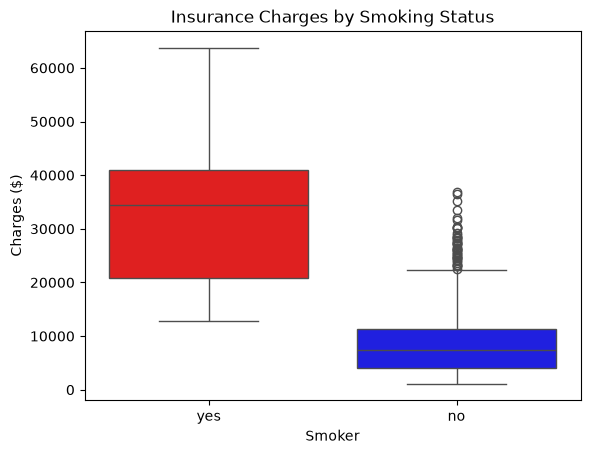

In [ ]:
import seaborn as sns

# clean boxplot
sns.boxplot(data=df, x='smoker', y='charges',
            palette={'yes': 'red', 'no': 'blue'})
plt.title('Insurance Charges by Smoking Status')
plt.xlabel('Smoker')
plt.ylabel('Charges ($)')
plt.show()


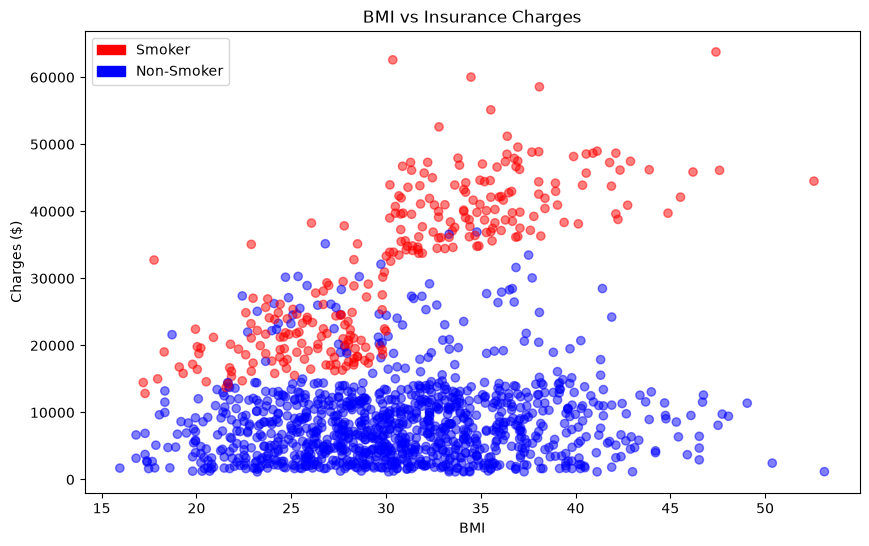

In [ ]:
from matplotlib.patches import Patch
colors = df['smoker'].map({'yes': 'red', 'no': 'blue'})

plt.figure(figsize=(10, 6))
plt.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')

# add legend manually
legend = [Patch(color='red', label='Smoker'),
          Patch(color='blue', label='Non-Smoker')]
plt.legend(handles=legend)
plt.show()


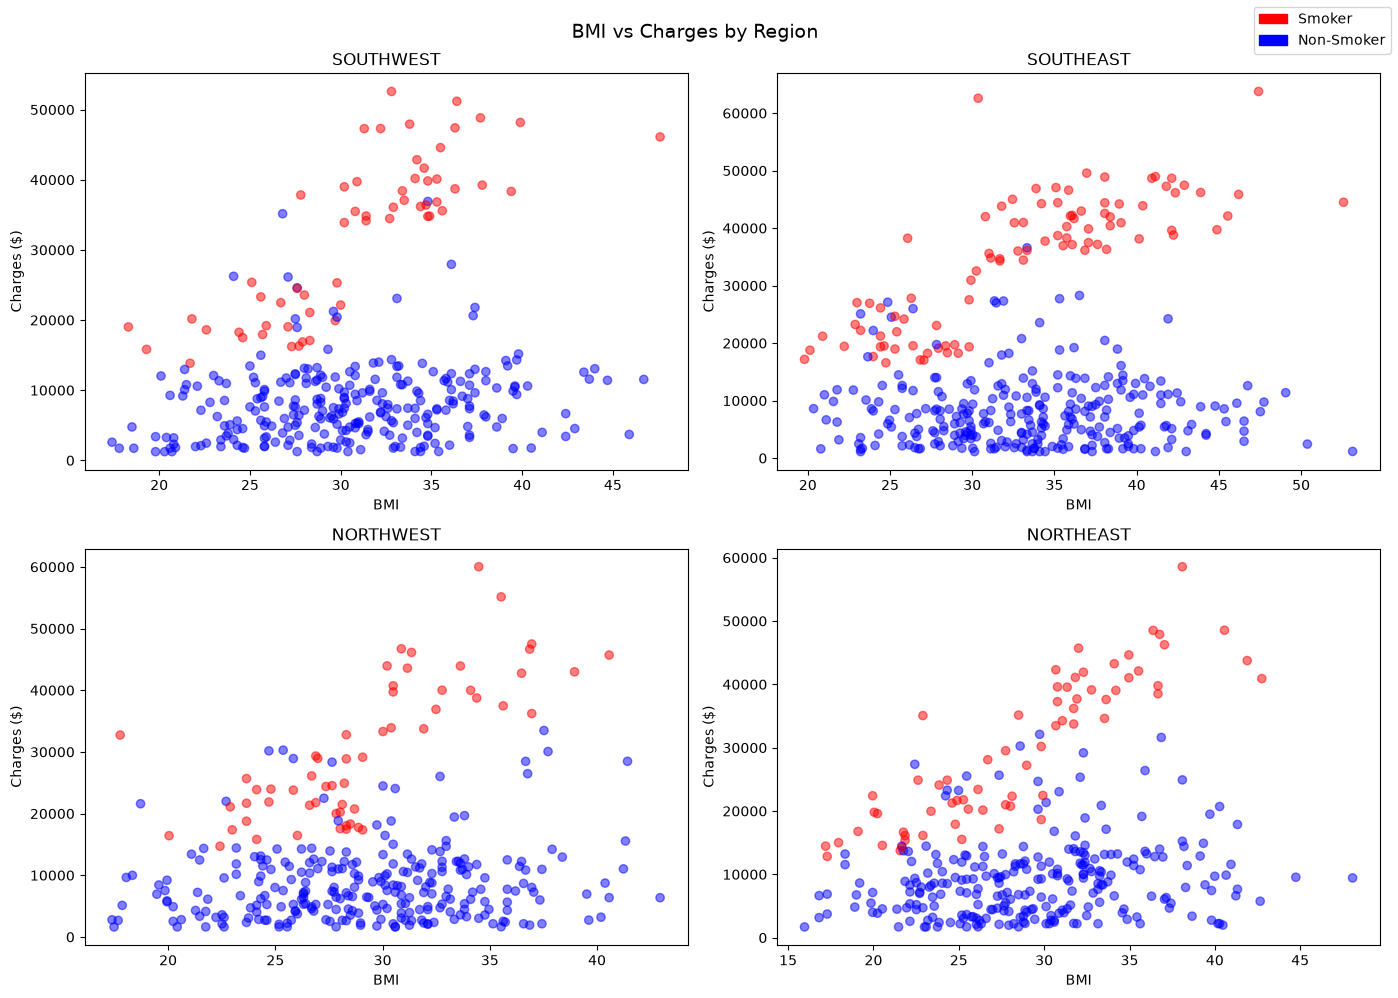

In [ ]:
# BMI vs Charges by region, colored by smoker
from matplotlib.patches import Patch
regions = df['region'].unique()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, region in zip(axes, regions):
    subset = df[df['region'] == region]
    colors = subset['smoker'].map({'yes': 'red', 'no': 'blue'})
    ax.scatter(subset['bmi'], subset['charges'], c=colors, alpha=0.5)
    ax.set_title(f'{region.upper()}')
    ax.set_xlabel('BMI')
    ax.set_ylabel('Charges ($)')

# shared legend
legend = [Patch(color='red', label='Smoker'),
          Patch(color='blue', label='Non-Smoker')]
fig.legend(handles=legend, loc='upper right')
fig.suptitle('BMI vs Charges by Region', fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# mean charges by sex and smoker status
df.groupby(['sex', 'smoker'])['charges'].mean()


sex     smoker
female  no         8762.297300
        yes       30678.996276
male    no         8087.204731
        yes       33042.005975
Name: charges, dtype: float64

In [ ]:
female_non = df[(df['sex'] == 'female') & (df['smoker'] == 'no')]['charges']
male_non = df[(df['sex'] == 'male') & (df['smoker'] == 'no')]['charges']

t_stat, p_value = stats.ttest_ind(female_non, male_non)
print(f'p-value: {p_value}')

if p_value < 0.05:
    print('Difference is statistically significant')
else:
    print('Difference is NOT statistically significant')


p-value: 0.06629758276709075
Difference is NOT statistically significant


In [ ]:
female_yes = df[(df['sex'] == 'female') & (df['smoker'] == 'yes')]['charges']
male_yes = df[(df['sex'] == 'male') & (df['smoker'] == 'yes')]['charges']

t_stat, p_value = stats.ttest_ind(female_yes, male_yes)
print(f'p-value: {p_value}')


p-value: 0.09447953030991106


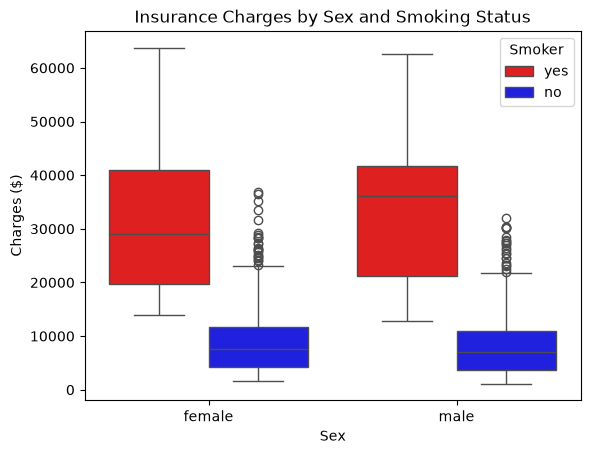

In [ ]:
sns.boxplot(data=df, x='sex', y='charges', hue='smoker',
            palette={'yes': 'red', 'no': 'blue'})
plt.title('Insurance Charges by Sex and Smoking Status')
plt.xlabel('Sex')
plt.ylabel('Charges ($)')
plt.legend(title='Smoker')
plt.show()


In [27]:
df['smoker_encoded'] = df['smoker'].map({'yes': 1, 'no': 0})
df['smoker_encoded'].corr(df['charges'])


np.float64(0.7872514304984778)

In [ ]:
df[['age', 'bmi', 'children', 'charges']].corr(
)['charges'].sort_values(ascending=False)


charges     1.000000
age         0.299008
bmi         0.198341
children    0.067998
Name: charges, dtype: float64

In [29]:
smokers = df[df['smoker'] == 'yes']
non_smokers = df[df['smoker'] == 'no']

print(smokers['bmi'].corr(smokers['charges']))
print(non_smokers['bmi'].corr(non_smokers['charges']))


0.8064806070155401
0.0840365431283327
